In [5]:
# Zee is a company that provides personalised user experiences to its users. 
# This is usually done through be-spoke movie recommendations
# In this case study multiple recommendation system techniques are used to create recommendations.
# General techniques are Collaborative and Content-based filtering

In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings

from scipy import sparse

from cmfrec import CMF
from surprise import Reader, SVD, Dataset
from surprise.model_selection import cross_validate

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error

In [29]:
# Read movies
movies = pd.read_fwf("zee-movies.dat", encoding="ISO-8859-1")
print(movies.shape)
movies.head()

(3883, 3)


,Movie ID::Title::Genres,Unnamed: 1,Unnamed: 2
0,1::Toy Story (1995)::Animation|Children's|Comedy,NaN,NaN
1,2::Jumanji (1995)::Adventure|Children's|Fantasy,NaN,NaN
2,3::Grumpier Old Men (1995)::Comedy|Romance,NaN,NaN
3,4::Waiting to Exhale (1995)::Comedy|Drama,NaN,NaN
4,5::Father of the Bride Part II (1995)::Comedy,NaN,NaN


In [31]:
# Drop the columns
movies.drop(columns=["Unnamed: 1", "Unnamed: 2"], axis=1, inplace=True)
# Process
delim = "::"
movies = movies["Movie ID::Title::Genres"].str.split(delim, expand=True)
movies.columns = ["Movie ID", "Title", "Genres"]
movies.rename(columns={"Movie ID": "MovieID"}, inplace=True)
movies1 = movies.copy()
movies.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [33]:
# Read ratings
ratings = pd.read_fwf("zee-ratings.dat", encoding="ISO-8859-1")
print(ratings.shape)
ratings.head()

(1000209, 1)


,UserID::MovieID::Rating::Timestamp
0,1::1193::5::978300760
1,1::661::3::978302109
2,1::914::3::978301968
3,1::3408::4::978300275
4,1::2355::5::978824291


In [35]:
# Process
delim = "::"
ratings = ratings["UserID::MovieID::Rating::Timestamp"].str.split(delim, expand=True)
ratings.columns = ["UserID", "MovieID", "Rating", "Timestamp"]
ratings1 = ratings.copy()
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [37]:
# Read Users
users = pd.read_fwf("zee-users.dat", encoding="ISO-8859-1")
print(users.shape)
users.head()

(6040, 1)


,UserID::Gender::Age::Occupation::Zip-code
0,1::F::1::10::48067
1,2::M::56::16::70072
2,3::M::25::15::55117
3,4::M::45::7::02460
4,5::M::25::20::55455


In [39]:
# Process
delim = "::"
users = users["UserID::Gender::Age::Occupation::Zip-code"].str.split(delim, expand=True)
users.columns = ["UserID", "Gender", "Age", "Occupation", "Zip-code"]
users1 = users.copy()
users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [41]:
# Create mapping
# Age mapping
users.replace({'Age':{'1':  "Under 18",
                      '18':  "18-24",
                      '25':  "25-34",
                      '35':  "35-44",
                      '45':  "45-49",
                      '50':  "50-55",
                      '56':  "56 Above"}}, inplace=True)

In [43]:
# Occupation mapping
users.replace({'Occupation':{'0': "other",
                             '1': "academic/educator",
                             '2': "artist",
                             '3': "clerical/admin",
                             '4': "college/grad student",
                             '5': "customer service",
                             '6': "doctor/health care",
                             '7': "executive/managerial",
                             '8': "farmer",
                             '9': "homemaker",
                             '10': "k-12 student",
                             '11': "lawyer",
                             '12': "programmer",
                             '13': "retired",
                             '14': "sales/marketing",
                             '15': "scientist",
                             '16': "self-employed",
                             '17': "technician/engineer",
                             '18': "tradesman/craftsman",
                             '19': "unemployed",
                             '20': "writer"}}, inplace=True)

In [45]:
users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,Under 18,k-12 student,48067
1,2,M,56 Above,self-employed,70072
2,3,M,25-34,scientist,55117
3,4,M,45-49,executive/managerial,02460
4,5,M,25-34,writer,55455


In [ ]:
# Data processing

In [71]:
# Remove year from the title
movies["Year"] = movies["Title"].str.extract('(\(\d\d\d\d\))', expand=False)
movies["Year"] = movies["Year"].str.extract('(\d\d\d\d)', expand=False)
movies["Title"] = movies["Title"].str.replace('(\(\d\d\d\d\))', '')
movies["Title"] = movies["Title"].apply(lambda x: x.strip())
movies.head()

<>:2: SyntaxWarning: invalid escape sequence '\('
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\('
/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_18747/1930780407.py:2: SyntaxWarning: invalid escape sequence '\('
  movies["Year"] = movies["Title"].str.extract('(\(\d\d\d\d\))', expand=False)
/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_18747/1930780407.py:3: SyntaxWarning: invalid escape sequence '\d'
  movies["Year"] = movies["Year"].str.extract('(\d\d\d\d)', expand=False)
/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_18747/1930780407.py:4: SyntaxWarning: invalid escape sequence '\('
  movies["Title"] = movies["Title"].str.replace('(\(\d\d\d\d\))', '')


,MovieID,Title,Genres,Year
0,1,Toy Story (1995),Animation|Children's|Comedy,1995
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


In [73]:
# Process the features
df_mov = movies.copy()
df_mov.dropna(inplace=True)
df_mov["Genres"] = df_mov["Genres"].str.split("|")
df_mov["Genres"] = df_mov["Genres"].apply(lambda x: [i for i in x if i!='A' and i!='D' and i!='F' and i!='C' and i!='M' and i!='W' and i!=' '])
for i in df_mov["Genres"]:
    for j in range(len(i)):
        if i[j] == 'Ro' or i[j] == 'Rom' or i[j] == 'Roman' or i[j] == 'R' or i[j] == 'Roma':
            i[j] = 'Romance'
        elif i[j] == 'Chil' or i[j] == 'Childre' or i[j] == 'Childr' or i[j] == "Children'" or i[j] =='Children' or i[j] =='Chi':
            i[j] = "Children's"
        elif i[j] == 'Fantas' or i[j] == 'Fant':
            i[j] = 'Fantasy'
        elif i[j] == 'Dr' or i[j] == 'Dram':
            i[j] = 'Drama'
        elif i[j] == 'Documenta'or i[j] == 'Docu' or i[j] == 'Document' or i[j] == 'Documen':
            i[j] = 'Documentary'
        elif i[j] == 'Wester'or i[j] == 'We':
            i[j] = 'Western'
        elif i[j] == 'Animati':
            i[j] = 'Animation'
        elif i[j] == 'Come'or i[j] == 'Comed' or i[j] == 'Com':
            i[j] = 'Comedy'
        elif i[j] == 'Sci-F'or i[j] == 'S' or i[j] == 'Sci-' or i[j] == 'Sci':
            i[j] = 'Sci-Fi'
        elif i[j] == 'Adv'or i[j] == 'Adventu' or i[j] == 'Adventur' or i[j] == 'Advent':
            i[j] = 'Adventure'
        elif i[j] == 'Horro'or i[j] == 'Horr':
            i[j] = 'Horror'
        elif i[j] == 'Th'or i[j] == 'Thri' or i[j] == 'Thrille':
            i[j] = 'Thriller'
        elif i[j] == 'Acti':
            i[j] = 'Action'
        elif i[j] == 'Wa':
            i[j] = 'War'
        elif i[j] == 'Music':
            i[j] = 'Musical'
df_mov.head()

,MovieID,Title,Genres,Year
0,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995
1,2,Jumanji (1995),"[Adventure, Children's, Fantasy]",1995
2,3,Grumpier Old Men (1995),"[Comedy, Romance]",1995
3,4,Waiting to Exhale (1995),"[Comedy, Drama]",1995
4,5,Father of the Bride Part II (1995),[Comedy],1995


In [75]:
# Join the dataftames
df1 = pd.merge(df_mov, ratings, how="inner", on="MovieID")
data = pd.merge(df1, users, how="inner", on="UserID")
data.head()

,MovieID,Title,Genres,Year,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code
0,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,1,5,978824268,F,Under 18,k-12 student,48067
1,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,6,4,978237008,F,50-55,homemaker,55117
2,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,8,4,978233496,M,25-34,programmer,11413
3,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,9,5,978225952,M,25-34,technician/engineer,61614
4,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,10,5,978226474,F,35-44,academic/educator,95370


In [77]:
# Shape of the data
data.shape

(996144, 11)

In [79]:
# General info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996144 entries, 0 to 996143
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   MovieID     996144 non-null  object
 1   Title       996144 non-null  object
 2   Genres      996144 non-null  object
 3   Year        996144 non-null  object
 4   UserID      996144 non-null  object
 5   Rating      996144 non-null  object
 6   Timestamp   996144 non-null  object
 7   Gender      996144 non-null  object
 8   Age         996144 non-null  object
 9   Occupation  996144 non-null  object
 10  Zip-code    996144 non-null  object
dtypes: object(11)
memory usage: 83.6+ MB


In [81]:
# Feature engineering
data["Datetime"] = pd.to_datetime(data["Timestamp"], unit="s")
data["Year"] = data["Year"].astype('int32')
data["Rating"] = data["Rating"].astype('int32')

/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_18747/36234889.py:2: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  data["Datetime"] = pd.to_datetime(data["Timestamp"], unit="s")


In [83]:
# Add decades information
bins = [1919, 1929, 1939, 1949, 1959, 1969, 1979, 1989, 2000]
labels = ['20', '30', '40', '50', '60', '70', '80', '90']
data["ReleaseDecade"] = pd.cut(data["Year"], bins=bins, labels=labels)
data.head()

,MovieID,Title,Genres,Year,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Datetime,ReleaseDecade
0,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,1,5,978824268,F,Under 18,k-12 student,48067,2001-01-06 23:37:48,90
1,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,6,4,978237008,F,50-55,homemaker,55117,2000-12-31 04:30:08,90
2,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,8,4,978233496,M,25-34,programmer,11413,2000-12-31 03:31:36,90
3,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,9,5,978225952,M,25-34,technician/engineer,61614,2000-12-31 01:25:52,90
4,1,Toy Story (1995),"[Animation, Children's, Comedy]",1995,10,5,978226474,F,35-44,academic/educator,95370,2000-12-31 01:34:34,90


[]

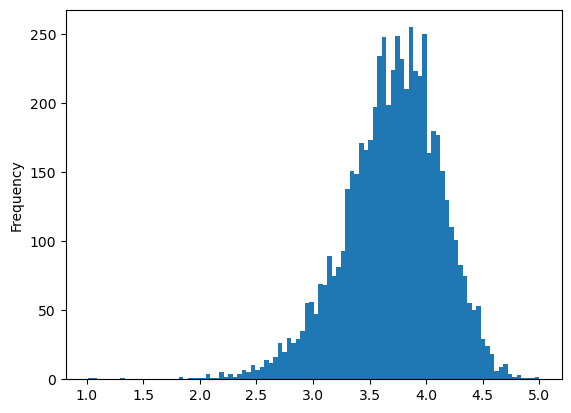

In [85]:
# Exploratory Data Analysis (EDA)
# Average user ratings
user_ratings = data.groupby("UserID")["Rating"].mean()
user_ratings.plot(kind="hist", bins=100)
plt.plot()

<Axes: xlabel='ReleaseDecade', ylabel='count'>

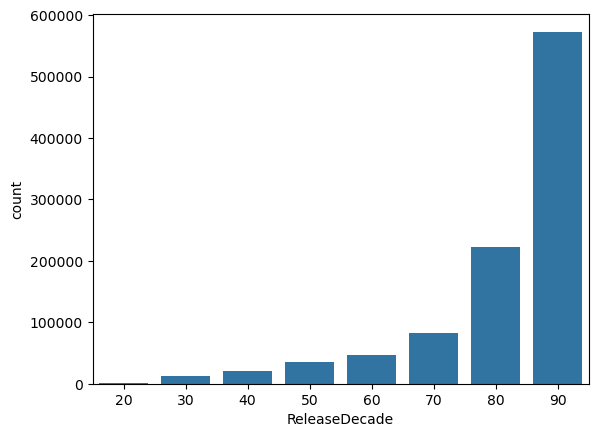

In [87]:
# Number of movies by released decade
sns.countplot(x="ReleaseDecade", data=data)

In [99]:
# Top genres by movies count
genres_df = pd.get_dummies(df_mov["Genres"].apply(pd.Series).stack())
calc_total = genres_df.iloc[:, 0:].sum().iloc[1:]
print(calc_total)

Action          501
Adventure       282
Animation       104
Children's      249
Comedy         1189
Crime           210
Documentary     124
Drama          1582
Fantasy          62
Film-Noir        44
Horror          340
Musical         113
Mystery         105
Romance         462
Sci-Fi          265
Thriller        488
War             139
Western          68
dtype: int64


<Axes: xlabel='Age', ylabel='count'>

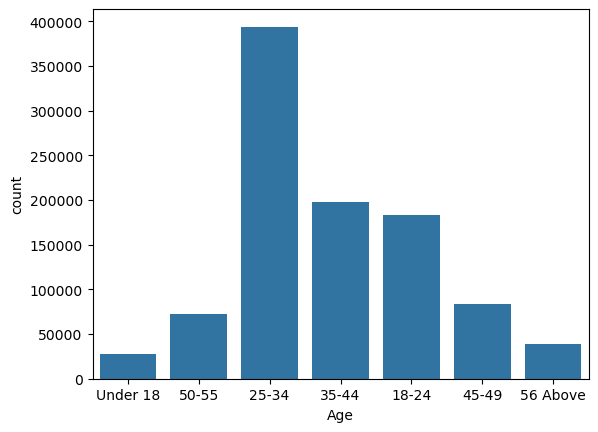

In [101]:
# Number of users by age
sns.countplot(x="Age", data=data)

<Axes: xlabel='Gender', ylabel='count'>

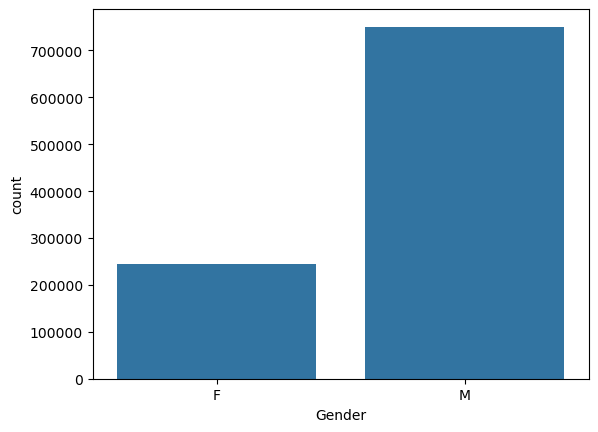

In [103]:
# Number of users by gender
sns.countplot(x="Gender", data=data)

<Axes: xlabel='count', ylabel='Occupation'>

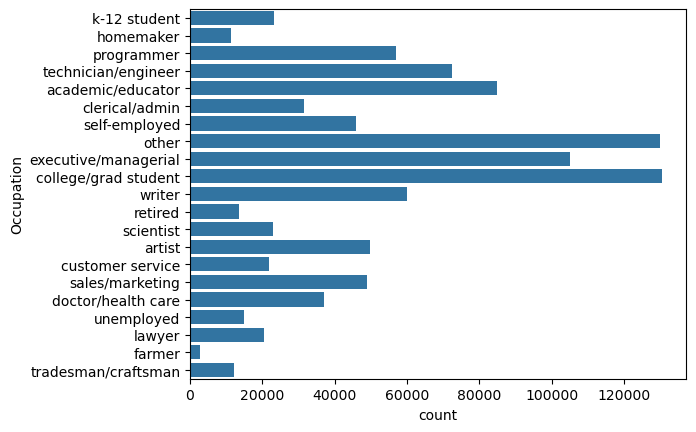

In [107]:
# Number of users by Occupation
sns.countplot(y="Occupation", data=data)

In [113]:
# Movies rating
movies_rating_count = data.groupby("Title")["Rating"].count().reset_index().sort_values(by="Rating", ascending=False).head(10)
movies_rating_count

,Title,Rating
126,American Beauty (1999),3428
3135,Star Wars: Episode IV - A New Hope (1977),2991
3136,Star Wars: Episode V - The Empire Strikes Back...,2990
3137,Star Wars: Episode VI - Return of the Jedi (1983),2883
1777,Jurassic Park (1993),2672
2877,Saving Private Ryan (1998),2653
3274,Terminator 2: Judgment Day (1991),2649
2098,"Matrix, The (1999)",2590
257,Back to the Future (1985),2583
2972,"Silence of the Lambs, The (1991)",2578


In [115]:
# Recommendations Systems

In [117]:
# User interaction matrix
matrix = pd.pivot_table(data, index="UserID", columns="Title", values="Rating", aggfunc="mean")
matrix.fillna(0, inplace=True)
print(matrix.shape)
matrix.head()

(6040, 3682)


Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjærlighetens kjøtere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
UserID,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,5.0


In [121]:
# Item based similarity
data[data["Title"] == "Home Alone (1990)"]

,MovieID,Title,Genres,Year,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Datetime,ReleaseDecade
156020,586,Home Alone (1990),"[Children's, Comedy]",1990,10,3,978228747,F,35-44,academic/educator,95370,2000-12-31 02:12:27,90
156021,586,Home Alone (1990),"[Children's, Comedy]",1990,11,1,978904356,F,25-34,academic/educator,04093,2001-01-07 21:52:36,90
156022,586,Home Alone (1990),"[Children's, Comedy]",1990,18,4,978155233,F,18-24,clerical/admin,95825,2000-12-30 05:47:13,90
156023,586,Home Alone (1990),"[Children's, Comedy]",1990,22,3,978154267,M,18-24,scientist,53706,2000-12-30 05:31:07,90
156024,586,Home Alone (1990),"[Children's, Comedy]",1990,26,2,978140049,M,25-34,executive/managerial,23112,2000-12-30 01:34:09,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
156690,586,Home Alone (1990),"[Children's, Comedy]",1990,5991,3,1000092830,F,35-44,writer,94025,2001-09-10 03:33:50,90
156691,586,Home Alone (1990),"[Children's, Comedy]",1990,5996,3,966275845,F,25-34,other,87114,2000-08-14 17:57:25,90
156692,586,Home Alone (1990),"[Children's, Comedy]",1990,6000,3,956884722,M,45-49,technician/engineer,30075,2000-04-28 01:18:42,90
156693,586,Home Alone (1990),"[Children's, Comedy]",1990,6006,2,957033431,F,Under 18,other,01036,2000-04-29 18:37:11,90


In [125]:
movie_name = "Home Alone (1990)"
movie_rating = matrix[movie_name]
print(movie_rating)

UserID
1       0.0
10      3.0
100     0.0
1000    0.0
1001    0.0
       ... 
995     0.0
996     0.0
997     0.0
998     0.0
999     0.0
Name: Home Alone (1990), Length: 6040, dtype: float64


In [129]:
# Identify similar movies
similar_movies = matrix.corrwith(movie_rating)
sim_df = pd.DataFrame(similar_movies, columns=['Correlation'])
sim_df.sort_values('Correlation', ascending=False, inplace=True)
sim_df.head()

,Correlation
Title,
Home Alone (1990),1.000000
Home Alone 2: Lost in New York (1992),0.547203
Mrs. Doubtfire (1993),0.468281
Liar Liar (1997),0.455967
"Mighty Ducks, The (1992)",0.446273


In [135]:
# Cosine similarity - Item based
item_sim = cosine_similarity(matrix.T)
item_sim_matrix = pd.DataFrame(item_sim, index=matrix.columns, columns=matrix.columns)
item_sim_matrix.head()

Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjærlighetens kjøtere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck (1971)",1.000000,0.072357,0.037011,0.079291,0.060838,0.00000,0.058619,0.189965,0.172254,0.094785,...,0.038725,0.076474,0.000000,0.044074,0.0,0.045280,0.039395,0.000000,0.120242,0.027003
'Night Mother (1986),0.072357,1.000000,0.115290,0.115545,0.159526,0.00000,0.076798,0.147437,0.095922,0.111413,...,0.053010,0.087828,0.063758,0.135962,0.0,0.091150,0.074787,0.000000,0.000000,0.077807
'Til There Was You (1997),0.037011,0.115290,1.000000,0.098756,0.066301,0.08025,0.127895,0.112654,0.125670,0.079115,...,0.029200,0.062893,0.000000,0.079187,0.0,0.022594,0.079261,0.000000,0.047526,0.063284
"'burbs, The (1989)",0.079291,0.115545,0.098756,1.000000,0.143620,0.00000,0.192191,0.246927,0.175885,0.170719,...,0.113386,0.207897,0.019962,0.138064,0.0,0.055704,0.161174,0.000000,0.033567,0.110525
...And Justice for All (1979),0.060838,0.159526,0.066301,0.143620,1.000000,0.00000,0.075093,0.194154,0.116379,0.205486,...,0.089998,0.153006,0.067009,0.109029,0.0,0.086080,0.110867,0.074317,0.000000,0.111040


In [137]:
# Cosine similarity - User based
user_sim = cosine_similarity(matrix)
user_sim_matrix = pd.DataFrame(user_sim, index=matrix.index, columns=matrix.index)
user_sim_matrix.head()

UserID,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
UserID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.255867,0.123967,0.207800,0.139266,0.110320,0.121384,0.179293,0.103896,0.052816,...,0.079367,0.038048,0.032136,0.066641,0.070052,0.035731,0.170184,0.159267,0.119356,0.122059
10,0.255867,1.000000,0.258633,0.279386,0.155439,0.112477,0.141431,0.429555,0.190388,0.102088,...,0.153811,0.186509,0.083413,0.123568,0.118096,0.145981,0.300856,0.160710,0.132807,0.246810
100,0.123967,0.258633,1.000000,0.297539,0.075708,0.110450,0.358686,0.236263,0.172872,0.099147,...,0.098235,0.097953,0.065152,0.176048,0.271311,0.033754,0.344290,0.204302,0.113522,0.306104
1000,0.207800,0.279386,0.297539,1.000000,0.094849,0.047677,0.201722,0.354078,0.325966,0.130702,...,0.170100,0.076779,0.000000,0.197410,0.380741,0.044404,0.330748,0.172803,0.098456,0.245292
1001,0.139266,0.155439,0.075708,0.094849,1.000000,0.164793,0.053867,0.149363,0.138551,0.134660,...,0.146216,0.026881,0.096975,0.117815,0.092201,0.109660,0.222037,0.100745,0.269852,0.175451


In [143]:
# KNN
model_knn = NearestNeighbors(metric="cosine")
model_knn.fit(matrix.T)

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [185]:
distances, indices = model_knn.kneighbors(matrix.T, n_neighbors=6)
result = pd.DataFrame(indices, columns=["Title1", "Title2", "Title3", "Title4", "Title5", "Title6"])
result.head()

,Title1,Title2,Title3,Title4,Title5,Title6
0,0,738,418,288,3283,586
1,1,810,73,2193,3072,3408
2,2,1642,2561,3359,2620,2021
3,3,1471,2195,1317,1053,3552
4,4,27,729,897,497,948


In [187]:
movies_list = matrix.T.reset_index().reset_index()[["index", "Title"]].set_index("index").to_dict()["Title"]
result["Title1"] = result["Title1"].map(lambda x: movies_list[x])
result["Title2"] = result["Title2"].map(lambda x: movies_list[x])
result["Title3"] = result["Title3"].map(lambda x: movies_list[x])
result["Title4"] = result["Title4"].map(lambda x: movies_list[x])
result["Title5"] = result["Title5"].map(lambda x: movies_list[x])
result["Title6"] = result["Title6"].map(lambda x: movies_list[x])
result.head()

,Title1,Title2,Title3,Title4,Title5,Title6
0,"$1,000,000 Duck (1971)","Computer Wore Tennis Shoes, The (1970)",Blackbeard's Ghost (1968),"Barefoot Executive, The (1971)",That Darn Cat! (1965),Candleshoe (1977)
1,'Night Mother (1986),"Cry in the Dark, A (1988)",Agnes of God (1985),Mommie Dearest (1981),Sophie's Choice (1982),"Trip to Bountiful, The (1985)"
2,'Til There Was You (1997),If Lucy Fell (1996),Picture Perfect (1997),To Gillian on Her 37th Birthday (1996),Practical Magic (1998),Mad Love (1995)
3,"'burbs, The (1989)",Harry and the Hendersons (1987),"Money Pit, The (1986)",Ghostbusters II (1989),European Vacation (1985),Weekend at Bernie's (1989)
4,...And Justice for All (1979),52 Pick-Up (1986),Coma (1978),Deliverance (1972),"Boys from Brazil, The (1978)",Dog Day Afternoon (1975)


In [189]:
result[result["Title1"] == "Liar Liar (1997)"]

,Title1,Title2,Title3,Title4,Title5,Title6
1907,Liar Liar (1997),Mrs. Doubtfire (1993),Ace Ventura: Pet Detective (1994),Dumb & Dumber (1994),Home Alone (1990),Wayne's World (1992)


In [191]:
# Matrix factorisation

In [193]:
rm = data.pivot(index="UserID", columns="MovieID", values="Rating").fillna(0)
rm.head()

MovieID,1,10,100,1000,1002,1003,1004,1005,1006,1007,...,99,990,991,992,993,994,996,997,998,999
UserID,,,,,,,,,,,,,,,,,,,,,
1,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1001,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [195]:
user_itm = data[["UserID", "MovieID", "Rating"]].copy()
user_itm.columns = ["UserId", "ItemId", "Rating"]
user_itm.head()

,UserId,ItemId,Rating
0,1,1,5
1,6,1,4
2,8,1,4
3,9,1,5
4,10,1,5


In [197]:
# Run matrix factorisation using CMF library
model = CMF(method="als", k=4, lambda_=0.1, user_bias=False, item_bias=False, verbose=False)
model.fit(user_itm)

Collective matrix factorization model
(explicit-feedback variant)


In [199]:
print(model.A_.shape) # User embeddings
print(model.B_.shape) # Item embeddings

(6040, 4)
(3682, 4)


In [203]:
print(user_itm["Rating"].mean())
print(model.glob_mean_)

3.57998542379415
3.5799853801727295


In [205]:
# Cosine similarity for users
user = cosine_similarity(model.A_)
user_sim_matrix = pd.DataFrame(user, index=matrix.index, columns=matrix.index)
user_sim_matrix.head()

UserID,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
UserID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.088071,0.363077,-0.249395,0.718839,0.332626,-0.010086,-0.625574,-0.449215,-0.569904,...,-0.496325,0.714248,0.437349,-0.171099,0.747023,0.197281,0.826462,-0.311508,0.945376,0.278515
10,-0.088071,1.000000,-0.512669,0.060343,0.581220,0.332946,0.154382,-0.569657,0.040254,0.778154,...,0.520589,0.616674,0.529285,0.321486,-0.210400,-0.671946,-0.586831,-0.008256,-0.406878,0.662923
100,0.363077,-0.512669,1.000000,0.659688,-0.069559,0.485551,0.656269,0.443273,0.451820,-0.261294,...,-0.066161,-0.179579,0.426872,0.103936,0.857165,0.880987,0.506354,0.234021,0.502849,0.279744
1000,-0.249395,0.060343,0.659688,1.000000,-0.195940,0.542989,0.924487,0.580667,0.891166,0.533799,...,0.604394,-0.278901,0.580906,0.369958,0.435822,0.550717,-0.294510,0.409843,-0.246904,0.562156
1001,0.718839,0.581220,-0.069559,-0.195940,1.000000,0.596941,-0.019080,-0.878569,-0.454072,0.046252,...,-0.203920,0.939292,0.632261,0.281837,0.416944,-0.394899,0.316750,-0.040268,0.475995,0.678730


In [209]:
# Cosine similarity for items
itm = cosine_similarity(model.B_)
itm_sim_matrix = pd.DataFrame(itm, index=user_itm['ItemId'].unique(), columns=user_itm['ItemId'].unique())
itm_sim_matrix.head()

,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
1,1.000000,0.263313,-0.057669,-0.139532,0.039765,0.678011,0.298002,0.065697,-0.300671,0.502066,...,-0.027189,-0.000002,-0.658259,-0.570073,0.335845,0.532963,0.294790,0.823914,0.820725,0.937063
2,0.263313,1.000000,0.925306,0.821672,0.951938,0.151237,0.954515,0.952180,0.779878,0.771437,...,0.573145,0.835843,0.481645,0.641556,0.411176,0.474100,-0.226857,0.574403,0.268283,0.505570
3,-0.057669,0.925306,1.000000,0.782591,0.966433,-0.000070,0.892112,0.891799,0.941381,0.727695,...,0.485327,0.792415,0.630422,0.824461,0.138416,0.440124,-0.356676,0.227343,-0.080343,0.207156
4,-0.139532,0.821672,0.782591,1.000000,0.837054,-0.283825,0.730584,0.948921,0.711902,0.287694,...,0.716278,0.856134,0.837236,0.826348,0.570795,-0.055691,-0.298090,0.381447,0.087454,0.098580
5,0.039765,0.951938,0.966433,0.837054,1.000000,-0.108141,0.961182,0.916869,0.833969,0.666295,...,0.420266,0.739239,0.618214,0.773521,0.196659,0.317606,-0.485157,0.332139,-0.027350,0.254528


In [217]:
# Surprise library
user_itm = data[["UserID", "Title", "Rating"]].copy()
reader = Reader(rating_scale=(1, 5))
data1 = Dataset.load_from_df(user_itm[["UserID", "Title", "Rating"]], reader)

In [221]:
svd = SVD(n_factors=4)
cross_validate(svd, data1, measures=["rmse"], cv=3, return_train_measures=True)

{'test_rmse': array([0.88872094, 0.89054365, 0.89085286]),
 'train_rmse': array([0.86000101, 0.86428168, 0.86016176]),
 'fit_time': (4.392388105392456, 4.711030006408691, 4.630164861679077),
 'test_time': (1.8909950256347656, 1.7822730541229248, 2.0737850666046143)}